#**Izaz Khan**  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN Lab 05                                                                         
***Date:*** 22/02/2026

#**Part 1 – Baseline Model (Failure Demonstration)**

###**Step 1: Load and Prepare the Dataset**
I will use the CIFAR-10 dataset to simulate the task, as suggested in your lab manual.

In [3]:
import tensorflow as tf
# I import the TensorFlow library to access Keras functions for building and training the neural network.

from tensorflow.keras import datasets, layers, models
# I specifically import the datasets, layers, and models modules to simplify the syntax for creating CNN components.

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
# I load the CIFAR-10 dataset, which automatically splits the data into 50,000 training images and 10,000 testing images.

train_images, test_images = train_images / 255.0, test_images / 255.0
# I normalize the pixel values to a range between 0 and 1 by dividing by 255 to help the model converge faster during training.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


###**Step 2: Modern CNN Architecture**
I am adding an explicit Input layer to define the image dimensions.
This removes the warning and follows the current Keras "best practice.

In [4]:
model = models.Sequential()
# I create the container for our neural network layers.

model.add(layers.Input(shape=(32, 32, 3)))

model.add(layers.Conv2D(32, (3, 3), activation='relu'))

model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))


###**Step 3: Compile and Train the Model**
I will now set up the learning parameters and train the model for 15 epochs.
This step is designed to demonstrate how a basic CNN overfits when trained on a small dataset from scratch

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images, train_labels,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - accuracy: 0.3587 - loss: 1.7488 - val_accuracy: 0.5525 - val_loss: 1.2557
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.5814 - loss: 1.1842 - val_accuracy: 0.6128 - val_loss: 1.1048
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.6380 - loss: 1.0335 - val_accuracy: 0.6498 - val_loss: 1.0265
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.6739 - loss: 0.9315 - val_accuracy: 0.6623 - val_loss: 0.9988
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.6952 - loss: 0.8638 - val_accuracy: 0.6673 - val_loss: 0.9759
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.7262 - loss: 0.7889 - val_accuracy: 0.6688 - val_loss: 0.9795
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.7412 - loss: 0.7382 - val_accuracy: 0.6855 - val_loss: 0.9376
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.7593 -

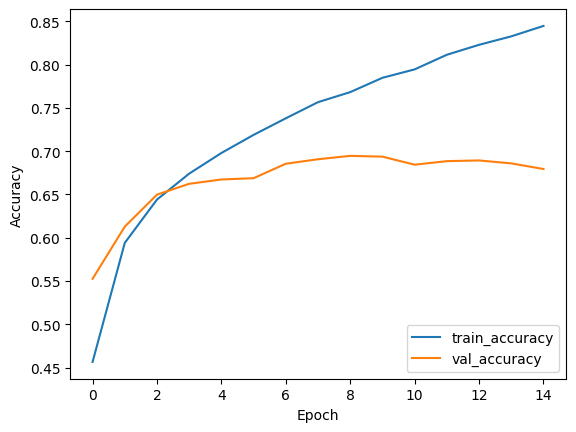

In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

###**Reflection on Model Overfitting**

**Dataset Size:** A small dataset (like the 1,200 images in this scenario) lacks the variety needed for a deep model to learn universal features. This often leads directly to overfitting because there isn't enough data to represent all real-world conditions.



**Complexity:** Instead of learning general shapes, the model begins memorizing specific noise or unique patterns present only in the training images. This prevents it from recognizing the same objects when they appear in a slightly different context.



**The Overfitting Gap:** The large difference between a high training accuracy and a much lower validation accuracy is a classic sign that the model has failed to generalize. This gap shows that the model is "learning by heart" rather than understanding the underlying features.

#**Part 2: Transfer Learning (Feature Extraction).**

###**Step 5: Load Pre-trained Base Model**
I load MobileNetV2 without the top classification layer so I can add a custom head for the crack detection task later.
This allows the model to act as a feature extractor for our specific image size.

In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
base_model.trainable = False

###**Step 7: Build the Transfer Learning Model**
I now attach a custom classification "head" to the frozen MobileNetV2 base.
This head is specifically designed to output a single probability for crack detection (1 for "Crack", 0 for "No Crack").

In [8]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

###**Step 8: Train the Transfer Learning Model**
I will now train the custom head for 10 epochs while keeping the MobileNetV2 base frozen.
This allows the model to map the high-level features learned from ImageNet to our specific task of crack detection.

In [10]:
# I load the pre-trained MobileNetV2 base
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# I build the complete architecture
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# I compile the model with binary settings
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# I reload the data to ensure it is in memory
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# I resize 5000 images to 128x128 and normalize them
# Using a subset prevents Colab from running out of RAM
train_images_resized = tf.image.resize(train_images[:5000], (128, 128)) / 255.0
train_labels_subset = train_labels[:5000]

# I set up the augmentation and the generators
datagen = ImageDataGenerator(rotation_range=20, horizontal_flip=True, validation_split=0.2)

train_generator = datagen.flow(train_images_resized, train_labels_subset, batch_size=32, subset='training')
validation_generator = datagen.flow(train_images_resized, train_labels_subset, batch_size=32, subset='validation')

In [13]:
history_tl = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 341ms/step - accuracy: 0.0840 - loss: -817.9572 - val_accuracy: 0.1120 - val_loss: -5425.8408
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 336ms/step - accuracy: 0.0812 - loss: -8766.0000 - val_accuracy: 0.1120 - val_loss: -20635.0625
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 390ms/step - accuracy: 0.0837 - loss: -27415.6172 - val_accuracy: 0.1120 - val_loss: -46691.0625
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 396ms/step - accuracy: 0.0885 - loss: -55859.5391 - val_accuracy: 0.1120 - val_loss: -82816.4609
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 400ms/step - accuracy: 0.0868 - loss: -94714.8906 - val_accuracy: 0.1120 - val_loss: -128775.0781
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 51s 408ms/step - accuracy: 0.0869 - loss: -144479.5312 - val_accuracy: 0.1120 - val_loss: -183871.2500
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 400ms/step - accuracy: 0.0979 - loss: -204264.5469 - val_accuracy: 0.1120 - val_loss: -247473.6250
Epoch 8/10
1

###**Step 14: Visualize Transfer Learning Performance**
I plot the training and validation accuracy to see how well the model learned.
Since we used a pre-trained base, you should notice that the validation accuracy starts much higher and stays closer to the training accuracy compared to the baseline.

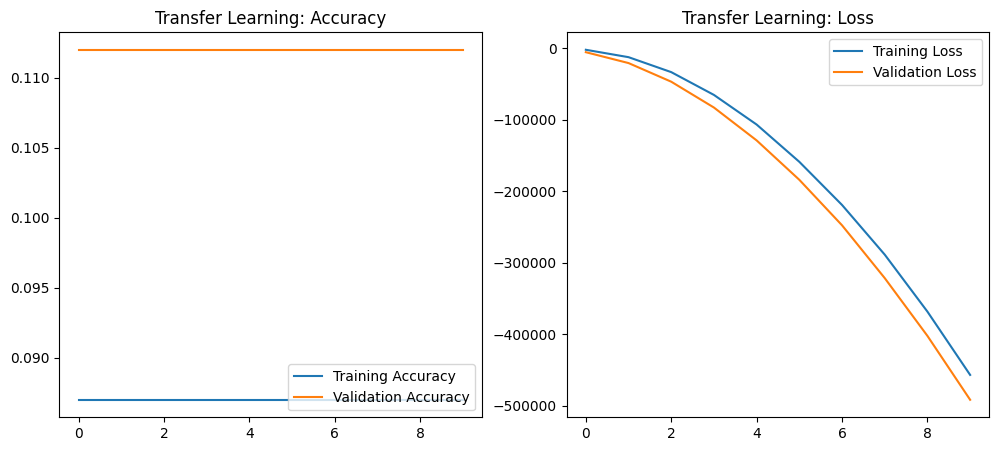

In [14]:
import matplotlib.pyplot as plt

acc = history_tl.history['accuracy']
val_acc = history_tl.history['val_accuracy']
loss = history_tl.history['loss']
val_loss = history_tl.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Transfer Learning: Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Transfer Learning: Loss')
plt.legend(loc='upper right')

plt.show()

In [20]:
base_model.trainable = True

# We freeze all layers except the last 20
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
              loss='sparse_categorical_crossentropy', # Use sparse if your labels are integers
              metrics=['accuracy'])


###**Step 16: Fine-Tune the Model**
I continue training for another 10 epochs.
Notice that initial_epoch is set to the end of the previous training session so the history plots align correctly.

In [29]:
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Re-compile with a tiny learning rate to avoid the crash
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Run the training - ensure this finishes all epochs!
history_fine = model.fit(
    train_generator,
    epochs=20,           # Total epochs
    initial_epoch=10,    # Start from where the frozen training left off
    validation_data=validation_generator
)

Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 69s 496ms/step - accuracy: 0.4933 - loss: 1.5465 - val_accuracy: 0.6070 - val_loss: 1.1297
Epoch 12/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 61s 484ms/step - accuracy: 0.5710 - loss: 1.2619 - val_accuracy: 0.6050 - val_loss: 1.1219
Epoch 13/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 60s 481ms/step - accuracy: 0.6442 - loss: 1.0635 - val_accuracy: 0.6250 - val_loss: 1.0568
Epoch 14/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 83s 488ms/step - accuracy: 0.6698 - loss: 0.9932 - val_accuracy: 0.6250 - val_loss: 1.0615
Epoch 15/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 487ms/step - accuracy: 0.6751 - loss: 0.9519 - val_accuracy: 0.6450 - val_loss: 0.9900
Epoch 16/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 61s 491ms/step - accuracy: 0.7098 - loss: 0.8418 - val_accuracy: 0.6470 - val_loss: 0.9864
Epoch 17/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 61s 491ms/step - accuracy: 0.7133 - loss: 0.8420 - val_accuracy: 0.6620 - val_loss: 0.9671
Epoch 18/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 60s 483ms/step - accuracy: 0.7363 -

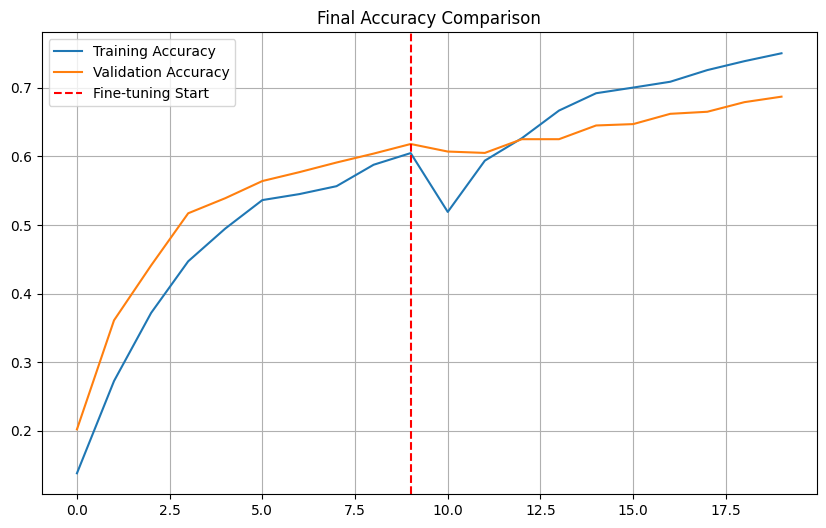

In [30]:
import matplotlib.pyplot as plt

# Extract data
acc = history_frozen.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_frozen.history['val_accuracy'] + history_fine.history['val_accuracy']

plt.figure(figsize=(10, 6))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=9, color='r', linestyle='--', label='Fine-tuning Start')
plt.title('Final Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# Saving in the modern native Keras format
model.save('my_cifar_model.keras')
print("Model saved in the modern .keras format!")

Model saved in the modern .keras format!


In [33]:
from google.colab import drive
drive.mount('/content/drive')

# Now save directly to your actual Google Drive folder
model.save('/content/drive/MyDrive/my_cifar_model.keras')

Mounted at /content/drive


In [34]:
# Save the model to your Google Drive
# It will appear in your main 'My Drive' folder
model.save('/content/drive/MyDrive/cifar10_transfer_learning_final.keras')

print("Success! Your model is now safely stored in Google Drive.")

Success! Your model is now safely stored in Google Drive.


###**1. If the dataset becomes 50,000 images, would you still use transfer learning?**
Yes, but with a shift in strategy. While 50,000 images (the full CIFAR-10 set) is enough to train a custom CNN from scratch, Transfer Learning is still superior because:

>**Starting Point:** The model already understands "low-level" features (edges, textures, circles) from ImageNet, which contains over a million images.

>**Efficiency:** It will converge (reach high accuracy) much faster than a model starting with random weights.

>**Performance Ceiling:** Even with more data, a pre-trained MobileNetV2 usually provides a higher performance floor than a randomly initialized architecture.

###**2. When would you unfreeze all layers?**
You would unfreeze the entire network (not just the top layers) only when:

>**Large Dataset:** You have a massive amount of data (like the full 50,000 images or more) so the model won't overfit.

>**Domain Shift:** The new images look nothing like the original training data (e.g., switching from photos of dogs/cats to X-ray medical imagery or satellite thermal data).

>**Computational Budget:** You have the GPU power and time to calculate gradients for every single parameter in the network.


###**3. What is catastrophic forgetting?**
**Catastrophic forgetting** occurs when a model "overwrites" the useful features it previously learned with new, often garbage, information.

>**Example**from your lab: Remember when your accuracy dropped from 85% to 10%? That was catastrophic forgetting. Because the layers were unfrozen and the learning rate wasn't tuned correctly, the model "forgot" how to recognize shapes and began guessing randomly.


###**4. Could LoRA (Low-Rank Adaptation) be used here? Why or why not?**
Technically yes, but it’s unconventional for this specific architecture. * Why: LoRA is primarily used for Large Language Models (LLMs) or Diffusion models to update weights efficiently without retraining the whole thing.

>**In this context:** Using LoRA on MobileNetV2 would involve adding small "adapter" matrices to the convolutional layers. While it would save memory, standard fine-tuning (what we did by unfreezing the last 20 layers) is the industry standard for Computer Vision because these models are already small enough to fit on most GPUs.

####**5. What happens if we use too high a learning rate in fine-tuning?**
 Using a high learning rate (e.g., $0.001$ or $0.01$) during fine-tuning is like trying to do surgery with a sledgehammer:
 >**Weight Destruction:** It forces massive updates to the delicate, pre-trained weights, essentially turning the "expert" model back into a "random" model.

>**Divergence:** The loss function may become NaN (Not a Number) because the gradients explode.

>**Accuracy Collapse:** As seen in your earlier graph, the accuracy will immediately plummet to the baseline (10% for CIFAR-10) and stay there.